# 11 — Liberation Day tariff event study

**Onderzoekshypothese**: rond Liberation Day (2 april 2025) en de daaropvolgende
tariff-escalatie/deëscalatie gebruikt Donald Trump zijn Truth Social account
doelbewust om marktprijzen te beïnvloeden.

**Aanpak**: dezelfde event-study methodiek als notebook 10 (Iran-conflict), maar
nu op tarieven. We kijken naar S&P 500 (SPY), sectoren die direct getroffen zijn
(XLI industrie, XLF finance, XLK tech) en de dollar (DXY).

**Tijdlijn:**
- **2 april 2025** — Liberation Day aankondiging (reciprocal tariffs, gemiddeld ~20%)
- **9 april 2025** — 90-daagse pauze voor alle landen *behalve* China
- **10+ april 2025** — China-escalatie (145% US tariff, 125% China counter-tariff)
- **12 mei 2025** — US-China 90-daagse truce (Genève deal, terug naar ~30%)

**Data sources:**
- `data/raw/posts.parquet` — Trump posts 2022-02-14 → 2026-04-23 (Kaggle archive)
- yfinance — SPY, XLI, XLF, XLK, DX-Y.NYB

**Plan:**
1. Filter tariff-gerelateerde posts met keyword-lijst.
2. Download dagelijkse + hourly marktdata.
3. Anchor events visualiseren op prijsgrafiek.
4. Per-post event-study: returns t-1h, t+1h, t+4h, t+24h.
5. Tariff posts vs. controle-posts: t-test.
6. Robustness: drop Liberation Day cluster zelf.
7. Top-10 meest impactvolle posts.
8. Sentiment / toxicity profiel.
9. Granger causaliteitstest.
10. Volume anomaliecheck.

In [15]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from datetime import date, datetime, timedelta
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

# Liberation Day = 2 april 2025
LIBERATION_DAY = pd.Timestamp("2025-04-02", tz="UTC")
# Analysevenster: 60 dagen voor t/m 90 dagen na Liberation Day
WINDOW_START = LIBERATION_DAY - pd.Timedelta(days=60)   # 2025-02-01
WINDOW_END   = LIBERATION_DAY + pd.Timedelta(days=90)   # 2025-07-01
TODAY = pd.Timestamp.now(tz="UTC").normalize()

print(f"Analysevenster: {WINDOW_START.date()} → {WINDOW_END.date()}")
print(f"Liberation Day: {LIBERATION_DAY.date()}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Analysevenster: 2025-02-01 → 2025-07-01
Liberation Day: 2025-04-02


## 1. Load posts

In [16]:
posts_path = Path("../data/raw/posts.parquet")
if not posts_path.exists():
    raise FileNotFoundError(f"Niet gevonden: {posts_path}")

all_posts = pd.read_parquet(posts_path)
all_posts["timestamp_utc"] = pd.to_datetime(all_posts["timestamp_utc"], utc=True)
all_posts["post_id"] = all_posts["post_id"].astype(str)
all_posts = all_posts.drop_duplicates(subset="post_id", keep="first")
all_posts = all_posts.sort_values("timestamp_utc").reset_index(drop=True)

# Filter op analysevenster
window_posts = all_posts[
    (all_posts["timestamp_utc"] >= WINDOW_START) &
    (all_posts["timestamp_utc"] <= WINDOW_END)
].copy()

print(f"Totale archive: {len(all_posts):,} posts")
print(f"In analysevenster ({WINDOW_START.date()} → {WINDOW_END.date()}): {len(window_posts):,} posts")
print(f"Date range venster: {window_posts['timestamp_utc'].min()} → {window_posts['timestamp_utc'].max()}")

Totale archive: 26,819 posts
In analysevenster (2025-02-01 → 2025-07-01): 2,090 posts
Date range venster: 2025-02-01 00:29:22.396000+00:00 → 2025-06-30 23:27:48.491000+00:00


## 2. Filter tariff-gerelateerde posts

Keyword-lijst dekt: directe tarifering, handelspolitiek, getroffen landen en sectoren.

In [17]:
TARIFF_KEYWORDS = [
    # Directe tarief-termen
    "tariff", "tariffs", "import duty", "import duties", "customs",
    "reciprocal", "liberation day",
    # Handelsbeleid
    "trade war", "trade deal", "trade deficit", "trade surplus",
    "trade negotiat", "free trade", "fair trade",
    "wto", "world trade organization",
    # Landen / blokken
    "china", "chinese", "beijing", "xi jinping",
    "europe", "european union", "eu ", "brussels",
    "canada", "mexico", "japan",
    # Handels-escalatie signalen
    "retaliat", "counter tariff", "sanction",
    "decouple", "decoupling", "supply chain",
    # Economisch
    "inflation", "consumer price", "cpi",
    "manufacturing", "jobs", "factory",
    # Deal-signalen
    "deal", "negotiat", "pause", "truce", "exemption",
]

pattern = "|".join(TARIFF_KEYWORDS)
mask_tariff = window_posts["text"].str.lower().str.contains(pattern, na=False, regex=True)

tariff_posts = window_posts[mask_tariff].copy()
control_posts = window_posts[~mask_tariff].copy()

print(f"Tariff posts: {len(tariff_posts):,}")
print(f"Controle posts: {len(control_posts):,}")
print()
print("Voorbeeld tariff posts:")
for _, row in tariff_posts.sample(min(3, len(tariff_posts)), random_state=42).iterrows():
    print(f"  [{row['timestamp_utc']}] {row['text'][:200]}")
    print()

Tariff posts: 364
Controle posts: 1,726

Voorbeeld tariff posts:
  [2025-04-10 13:38:03.061000+00:00] Just out: âINFLATION IS DOWN!!!â

  [2025-02-15 17:49:17.856000+00:00] https://www.breitbart.com/politics/2025/02/11/exclusive-sen-jim-banks-trump-brought-back-manufacturing-to-indiana-saved-the-american-dream/

  [2025-02-09 20:10:08.537000+00:00] https://www.wsj.com/opinion/trump-is-right-on-h-1b-visas-immigration-work-jobs-e3e9ec71



## 3. Download marktdata

Vijf tickers, 2 granulariteiten:
- **Daily** (full window) voor de overall picture.
- **Hourly** voor intraday event-study (yfinance max ~730 dagen terug).

In [18]:
TICKERS = {
    "SPY": "SPY",    # S&P 500
    "XLI": "XLI",    # Industrie (direct tariff-gevoelig)
    "XLK": "XLK",    # Tech (China-supply chain)
    "XLF": "XLF",    # Finance
    "DXY": "DX-Y.NYB",  # US Dollar index
}

def download_market(ticker_alias: str, ticker_symbol: str,
                    start: pd.Timestamp, interval: str = "1d") -> pd.DataFrame:
    df = yf.download(ticker_symbol, start=start.date(), interval=interval,
                     progress=False, auto_adjust=False)
    if df.empty:
        print(f"  LEEG: {ticker_alias} ({ticker_symbol})")
        return df
    df.columns = ([c.lower() for c in df.columns.get_level_values(0)]
                  if df.columns.nlevels > 1
                  else [c.lower() for c in df.columns])
    df = df.reset_index()
    df.columns = [c.lower() for c in df.columns]
    dt_col = next((c for c in df.columns if c in ["datetime", "date"]), df.columns[0])
    df = df.rename(columns={dt_col: "datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    df["ticker"] = ticker_alias
    df["return"] = np.log(df["close"] / df["close"].shift(1))
    return df[["datetime", "ticker", "open", "high", "low", "close",
               "volume", "return"]].dropna(subset=["close"])

# Daily — analysevenster
print("Downloading daily data...")
daily = pd.concat([
    download_market(alias, sym, WINDOW_START, "1d")
    for alias, sym in TICKERS.items()
], ignore_index=True)
print(f"Daily rows: {len(daily):,}")

# Hourly — yfinance ondersteunt max ~730 dagen terug; liberation day (apr 2025) moet beschikbaar zijn
print("\nDownloading hourly data...")
hourly = pd.concat([
    download_market(alias, sym, WINDOW_START, "1h")
    for alias, sym in TICKERS.items()
], ignore_index=True)
hourly_start = hourly["datetime"].min()
print(f"Hourly rows: {len(hourly):,}  |  start: {hourly_start}")

Daily rows: 1,711

Hourly rows: 17,692  |  start: 2025-02-02 22:00:00+00:00


## 4. Anchor events

Sleutelmomenten van de tariff-cyclus. Pas aan / vul aan naar bevinding.

In [19]:
ANCHOR_EVENTS = [
    # (datum, label, beschrijving)
    ("2025-04-02", "Liberation Day",        "Trump kondigt reciprocal tariffs aan op ~90 landen."),
    ("2025-04-09", "90-day pause",           "Tariffs gepauzeerd voor alle landen behalve China (125% → 145%)."),
    ("2025-04-10", "China escalatie",        "China verhoogt counter-tariff naar 125%; markt reageert."),
    ("2025-05-12", "US-China Genève truce",  "90-daagse truce: US tariff China terug naar ~30%."),
    ("2025-07-09", "90-day pause afloop",    "Einde van de 90-daagse pauze; onzekerheid over verlenging."),
]

anchor_df = pd.DataFrame(ANCHOR_EVENTS, columns=["date", "label", "description"])
anchor_df["date"] = pd.to_datetime(anchor_df["date"], utc=True)
print(anchor_df.to_string(index=False))

                     date                 label                                                      description
2025-04-02 00:00:00+00:00        Liberation Day              Trump kondigt reciprocal tariffs aan op ~90 landen.
2025-04-09 00:00:00+00:00          90-day pause Tariffs gepauzeerd voor alle landen behalve China (125% → 145%).
2025-04-10 00:00:00+00:00       China escalatie         China verhoogt counter-tariff naar 125%; markt reageert.
2025-05-12 00:00:00+00:00 US-China Genève truce                90-daagse truce: US tariff China terug naar ~30%.
2025-07-09 00:00:00+00:00   90-day pause afloop       Einde van de 90-daagse pauze; onzekerheid over verlenging.


## 5. Timeline: marktprijzen + post density + ankers

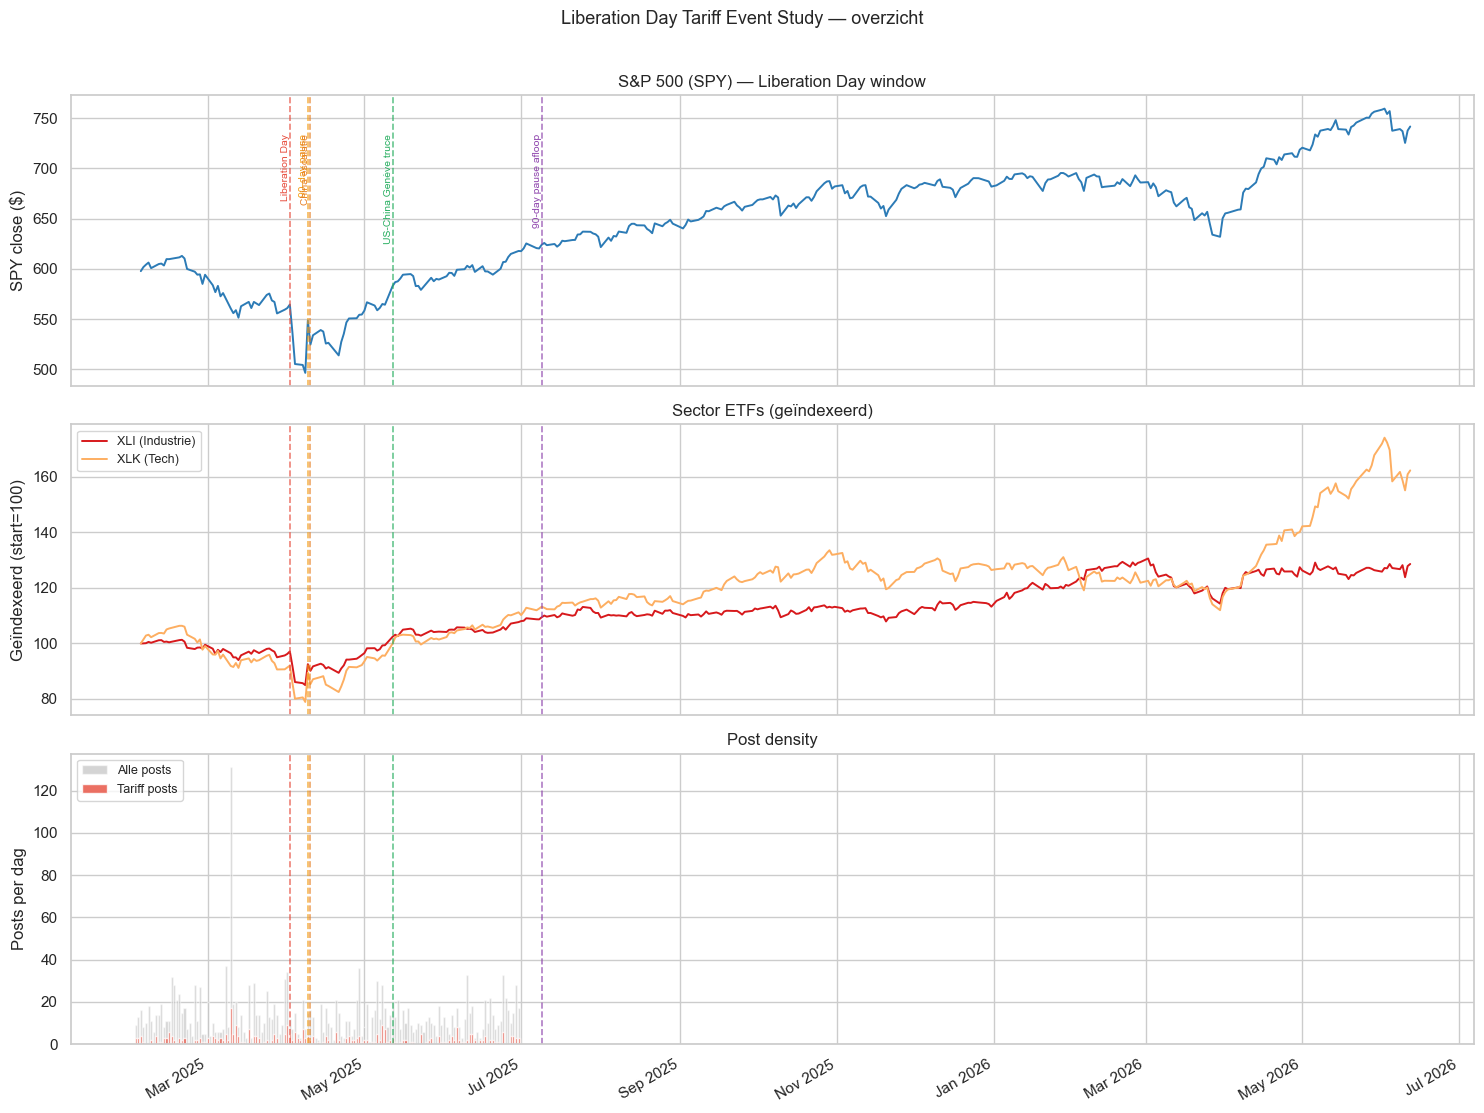

Opgeslagen: reports/figures/11_tariffs_timeline.png


In [20]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Top: SPY
spy_d = daily[daily["ticker"] == "SPY"].sort_values("datetime")
axes[0].plot(spy_d["datetime"], spy_d["close"], color="#2c7bb6", linewidth=1.4)
axes[0].set_ylabel("SPY close ($)")
axes[0].set_title("S&P 500 (SPY) — Liberation Day window")

# Middle: XLI + XLK
for alias, color, label in [("XLI", "#d7191c", "XLI (Industrie)"),
                             ("XLK", "#fdae61", "XLK (Tech)")]:
    sub = daily[daily["ticker"] == alias].sort_values("datetime")
    # Normalize to 100 at window start for comparison
    if len(sub) > 0:
        sub = sub.copy()
        sub["indexed"] = sub["close"] / sub["close"].iloc[0] * 100
        axes[1].plot(sub["datetime"], sub["indexed"], linewidth=1.4, label=label, color=color)
axes[1].set_ylabel("Geïndexeerd (start=100)")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].set_title("Sector ETFs (geïndexeerd)")

# Bottom: post density
window_posts["date_only"] = window_posts["timestamp_utc"].dt.date
tariff_posts["date_only"] = tariff_posts["timestamp_utc"].dt.date
daily_all = window_posts.groupby("date_only").size()
daily_tariff = tariff_posts.groupby("date_only").size()
dates_all = pd.to_datetime(daily_all.index, utc=True)
dates_tar = pd.to_datetime(daily_tariff.index, utc=True)
axes[2].bar(dates_all, daily_all.values, color="#aaaaaa", alpha=0.5, label="Alle posts", width=0.8)
axes[2].bar(dates_tar, daily_tariff.values, color="#e74c3c", alpha=0.8, label="Tariff posts", width=0.8)
axes[2].set_ylabel("Posts per dag")
axes[2].legend(loc="upper left", fontsize=9)
axes[2].set_title("Post density")

# Anchor events op alle subplots
colors_anch = ["#e74c3c", "#f39c12", "#e67e22", "#27ae60", "#8e44ad"]
for ax in axes:
    for (_, row), c in zip(anchor_df.iterrows(), colors_anch):
        if pd.notna(row["date"]):
            ax.axvline(row["date"], color=c, linestyle="--", alpha=0.7, linewidth=1.2)
            if ax == axes[0]:
                ax.text(row["date"], ax.get_ylim()[1]*0.95, row["label"],
                        rotation=90, va="top", ha="right", fontsize=7.5, color=c)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate(rotation=30)
plt.suptitle("Liberation Day Tariff Event Study — overzicht", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../reports/figures/11_tariffs_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Opgeslagen: reports/figures/11_tariffs_timeline.png")

## 6. Per-post event study (intraday)

Voor elke tariff-post: SPY/XLI/XLK/DXY return op t-1h, t+1h, t+4h, t+24h.

In [21]:
def compute_event_returns(post_time: pd.Timestamp, market_df: pd.DataFrame,
                          windows: list = [-1, 1, 4, 24]) -> dict:
    """Voor één post, log-returns voor de gegeven windows (uren)."""
    out = {}
    pre = market_df[market_df["datetime"] <= post_time]
    if pre.empty:
        return {f"ret_{w}h": np.nan for w in windows}
    p0 = pre.iloc[-1]["close"]
    for w in windows:
        target_time = post_time + pd.Timedelta(hours=w)
        if w < 0:
            sub = market_df[market_df["datetime"] <= target_time]
            p1 = sub.iloc[-1]["close"] if not sub.empty else np.nan
            out[f"ret_{w}h"] = float(np.log(p0 / p1)) if p1 else np.nan
        else:
            sub = market_df[market_df["datetime"] >= target_time]
            p1 = sub.iloc[0]["close"] if not sub.empty else np.nan
            out[f"ret_{w}h"] = float(np.log(p1 / p0)) if p1 else np.nan
    return out

# Alleen posts waarvoor hourly data beschikbaar is
tariff_in_h = tariff_posts[
    tariff_posts["timestamp_utc"] >= hourly_start
].copy()

print(f"Tariff posts in hourly window: {len(tariff_in_h)}")

event_rows = []
for _, row in tariff_in_h.iterrows():
    rec = {"post_id": row["post_id"], "timestamp_utc": row["timestamp_utc"],
           "text": row["text"]}
    for alias in TICKERS:
        market_t = hourly[hourly["ticker"] == alias].sort_values("datetime")
        rets = compute_event_returns(row["timestamp_utc"], market_t)
        for k, v in rets.items():
            rec[f"{alias}_{k}"] = v
    event_rows.append(rec)

event_df = pd.DataFrame(event_rows)
print(f"Event DataFrame shape: {event_df.shape}")
event_df[[c for c in event_df.columns if "SPY" in c or "XLI" in c]].describe().round(4)

Tariff posts in hourly window: 359
Event DataFrame shape: (359, 23)


,SPY_ret_-1h,SPY_ret_1h,SPY_ret_4h,SPY_ret_24h,XLI_ret_-1h,XLI_ret_1h,XLI_ret_4h,XLI_ret_24h
count,356.0000,356.0000,356.0000,356.0000,356.0000,356.0000,356.0000,356.0000
mean,-0.0001,-0.0012,-0.0010,-0.0002,-0.0002,-0.0008,-0.0006,0.0000
std,0.0044,0.0105,0.0128,0.0167,0.0045,0.0107,0.0132,0.0170
min,-0.0275,-0.0431,-0.0551,-0.0762,-0.0229,-0.0519,-0.0575,-0.0788
25%,0.0000,-0.0073,-0.0073,-0.0063,0.0000,-0.0060,-0.0058,-0.0066
50%,0.0000,-0.0007,-0.0001,0.0001,0.0000,-0.0008,-0.0009,0.0002
75%,0.0000,0.0030,0.0048,0.0071,0.0000,0.0042,0.0059,0.0080
max,0.0483,0.0750,0.0801,0.0612,0.0501,0.0764,0.0810,0.0623


## 7. Aggregaat-effect: tariff posts vs. controle-posts

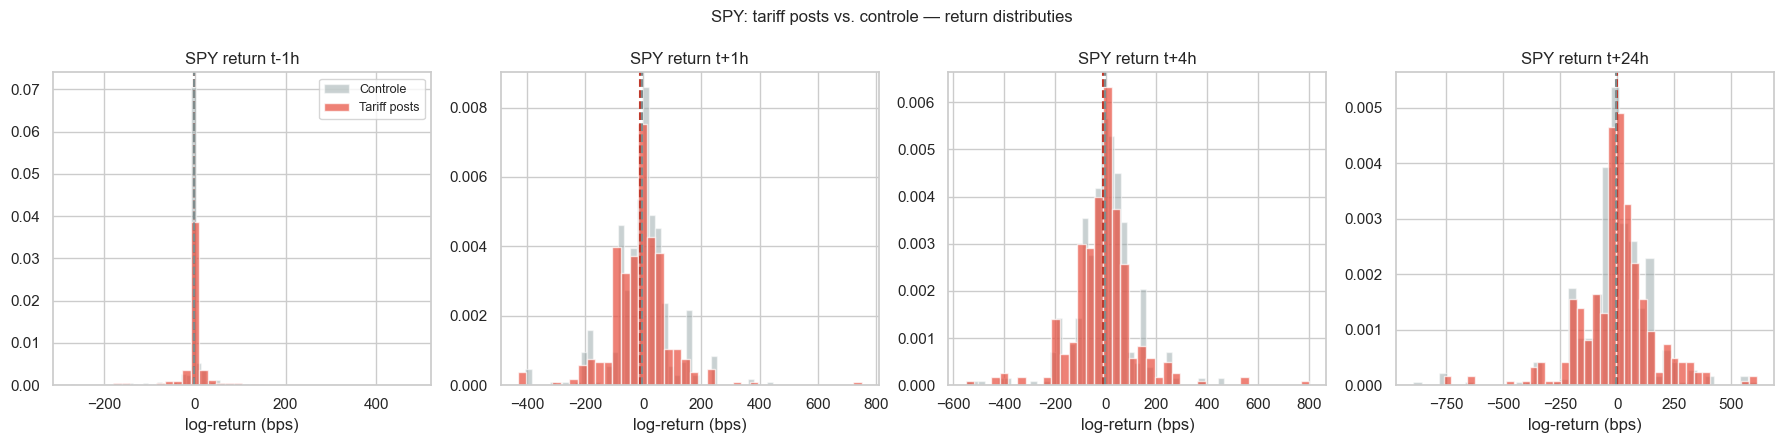

In [22]:
# Controle-groep: random sample non-tariff posts in zelfde hourly window
control_in_h = control_posts[
    control_posts["timestamp_utc"] >= hourly_start
].copy()
n_control = min(500, len(control_in_h))
control_sample = control_in_h.sample(n=n_control, random_state=42)

control_rows = []
for _, row in control_sample.iterrows():
    rec = {"post_id": row["post_id"], "timestamp_utc": row["timestamp_utc"]}
    for alias in TICKERS:
        market_t = hourly[hourly["ticker"] == alias].sort_values("datetime")
        rets = compute_event_returns(row["timestamp_utc"], market_t)
        for k, v in rets.items():
            rec[f"{alias}_{k}"] = v
    control_rows.append(rec)

control_df = pd.DataFrame(control_rows)

# Visualiseer distributies voor SPY
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=False)
windows = [-1, 1, 4, 24]
for ax, w in zip(axes, windows):
    col = f"SPY_ret_{w}h"
    tar_vals = event_df[col].dropna() * 1e4
    ctl_vals = control_df[col].dropna() * 1e4
    ax.hist(ctl_vals, bins=40, alpha=0.5, color="#95a5a6", label="Controle", density=True)
    ax.hist(tar_vals, bins=40, alpha=0.7, color="#e74c3c", label="Tariff posts", density=True)
    ax.axvline(tar_vals.mean(), color="#c0392b", linestyle="--", linewidth=1.5)
    ax.axvline(ctl_vals.mean(), color="#7f8c8d", linestyle="--", linewidth=1.5)
    ax.set_title(f"SPY return t{w:+d}h")
    ax.set_xlabel("log-return (bps)")
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.suptitle("SPY: tariff posts vs. controle — return distributies", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/11_tariffs_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Bootstrap 95%-CI per ticker x window (vervangt Welch t-toets)
from src.evaluation.bootstrap import bootstrap_diff_bp

test_rows = []
for alias in TICKERS:
    for w in [-1, 1, 4, 24]:
        col = f"{alias}_ret_{w}h"
        tar_vals = event_df[col].dropna()
        ctl_vals = control_df[col].dropna()
        if len(tar_vals) < 5 or len(ctl_vals) < 5:
            continue
        b = bootstrap_diff_bp(tar_vals, ctl_vals, stat=np.mean)
        test_rows.append({
            "ticker": alias, "window": f"{w:+d}h",
            "n_tariff": len(tar_vals), "n_ctrl": len(ctl_vals),
            "mean_tariff_bp": tar_vals.mean() * 1e4,
            "mean_ctrl_bp":   ctl_vals.mean() * 1e4,
            "diff_bp": b["obs_diff_bp"],
            "ci_low_bp": b["ci_low_bp"], "ci_high_bp": b["ci_high_bp"],
            "excludes_zero": b["excludes_zero"],
        })

tests = pd.DataFrame(test_rows).round(1)
print("=== Bootstrap 95%-CI: tariff posts vs control (mean-verschil, bp) ===")
print(tests.to_string(index=False))


=== Bootstrap 95%-CI: tariff posts vs control (mean-verschil, bp) ===
ticker window  n_tariff  n_ctrl  mean_tariff_bp  mean_ctrl_bp  diff_bp  ci_low_bp  ci_high_bp  excludes_zero
   SPY    -1h       356     499            -1.3          -1.9      0.6       -4.6         6.0          False
   SPY    +1h       356     499           -12.1          -3.4     -8.7      -22.5         5.6          False
   SPY    +4h       356     499           -10.2          -3.2     -6.9      -22.9         9.7          False
   SPY   +24h       356     499            -2.2          -4.3      2.1      -20.2        24.1          False
   XLI    -1h       356     499            -1.8          -0.8     -1.0       -6.3         4.3          False
   XLI    +1h       356     499            -8.0          -1.6     -6.4      -20.4         7.9          False
   XLI    +4h       356     499            -5.6          -2.2     -3.4      -20.2        13.8          False
   XLI   +24h       356     499             0.4          -

## 7b. Robustness: drop Liberation Day cluster (2–9 april 2025)

Check of het effect overeind blijft zonder de directe Liberation Day week.

In [24]:
from src.evaluation.bootstrap import bootstrap_diff_bp

LIBERATION_CLUSTER = pd.date_range("2025-04-02", "2025-04-09", tz="UTC").date

mask_cluster = event_df["timestamp_utc"].dt.date.isin(LIBERATION_CLUSTER)
event_no_cluster = event_df[~mask_cluster]
print(f"Tariff posts na drop Liberation Day cluster: {len(event_no_cluster)} (was {len(event_df)})")
print()

robust_rows = []
for alias in TICKERS:
    for w in [-1, 1, 4, 24]:
        col = f"{alias}_ret_{w}h"
        tar_no = event_no_cluster[col].dropna()
        ctl = control_df[col].dropna()
        if len(tar_no) < 5 or len(ctl) < 5:
            continue
        b = bootstrap_diff_bp(tar_no, ctl, stat=np.mean)
        robust_rows.append({
            "ticker": alias, "window": f"{w:+d}h",
            "n_no_cluster": len(tar_no),
            "diff_bp_no_cluster": b["obs_diff_bp"],
            "ci_low_bp": b["ci_low_bp"], "ci_high_bp": b["ci_high_bp"],
            "excludes_zero": b["excludes_zero"],
        })

robust = pd.DataFrame(robust_rows).round(1)
print(robust.to_string(index=False))


Tariff posts na drop Liberation Day cluster: 327 (was 359)

ticker window  n_no_cluster  diff_bp_no_cluster  ci_low_bp  ci_high_bp  excludes_zero
   SPY    -1h           324                 1.3       -3.1         5.5          False
   SPY    +1h           324                -5.9      -17.8         6.5          False
   SPY    +4h           324                -2.1      -16.0        12.1          False
   SPY   +24h           324                10.2       -8.7        29.4          False
   XLI    -1h           324                -0.8       -5.2         3.5          False
   XLI    +1h           324                -2.0      -14.0         9.9          False
   XLI    +4h           324                 2.7      -11.6        17.1          False
   XLI   +24h           324                14.8       -5.1        34.9          False
   XLK    -1h           324                 2.2       -3.6         8.0          False
   XLK    +1h           324                -6.2      -23.2        11.5          

## 8. Top-10 meest impactvolle tariff posts

In [25]:
event_df["SPY_abs_ret_1h"] = event_df["SPY_ret_1h"].abs()
top_impact = event_df.nlargest(10, "SPY_abs_ret_1h")

for _, row in top_impact.iterrows():
    direction = "↑" if row["SPY_ret_1h"] > 0 else "↓"
    print(
        f"[{row['timestamp_utc']}]  "
        f"SPY {direction}{abs(row['SPY_ret_1h'])*100:.2f}%  "
        f"XLI {row.get('XLI_ret_1h', np.nan)*100:+.2f}%  "
        f"DXY {row.get('DXY_ret_1h', np.nan)*100:+.2f}%"
    )
    print(f"  {str(row['text'])[:300]}")
    print()

[2025-04-09 16:16:12.535000+00:00]  SPY ↑7.50%  XLI +7.64%  DXY +0.45%
  Jon Husted is doing an incredible job as Senator for the Great State of Ohio! He served as your Lieutenant Governor for seven years prior to becoming a very distinguished and well respected Senator.Â Jon is a wonderful man, has ALWAYS delivered for Ohio, and will continue doing so in the U.S. Senate

[2025-04-03 19:18:34.961000+00:00]  SPY ↓4.31%  XLI -5.19%  DXY -0.19%
  https://www.rsbnetwork.com/news/michigan-autoworkers-express-support-for-trumps-tariffs/

[2025-04-03 19:19:18.683000+00:00]  SPY ↓4.31%  XLI -5.19%  DXY -0.19%
  https://www.rsbnetwork.com/news/trump-announces-wide-range-of-liberation-day-tariffs/

[2025-04-04 02:53:28.732000+00:00]  SPY ↓4.05%  XLI -4.90%  DXY -0.21%
  The Witch Hunt against Marine Le Pen is another example of European Leftists using Lawfare to silence Free Speech, and censor their Political Opponent, this time going so far as to put that Opponent in prison. It is the same âp

## 9. Sentiment + toxicity van tariff-posts

Gebruik onze eigen classifiers (notebook 08/09).

Classifiers geladen.
=== Sentiment ===
Tariff posts: {'positive': 0.503, 'neutral': 0.308, 'negative': 0.19}
Controle: {'neutral': 0.472, 'positive': 0.375, 'negative': 0.153}

=== Toxicity ===
Tariff posts toxic%: 0.192
Controle toxic%: 0.219


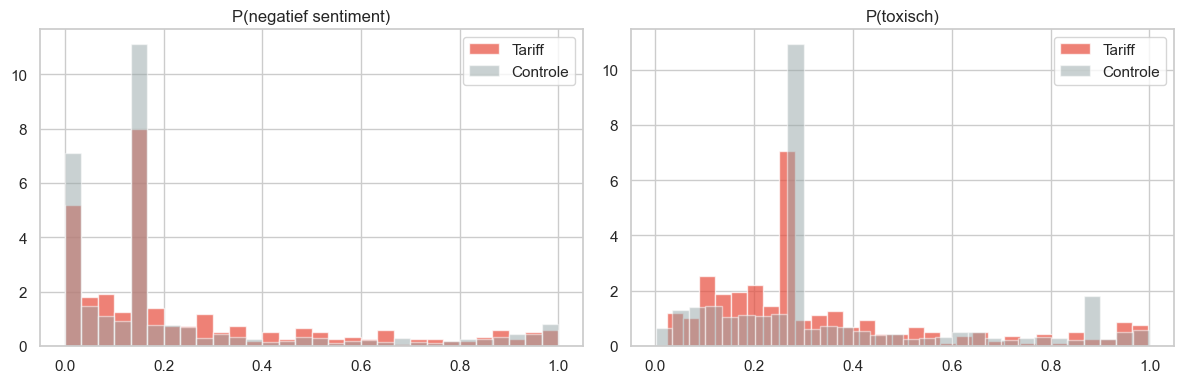

In [26]:
try:
    sentiment_vec = joblib.load("../models/sentiment/vectorizer.joblib")
    sentiment_clf = joblib.load("../models/sentiment/logistic_l1.joblib")
    toxicity_vec  = joblib.load("../models/toxicity/vectorizer.joblib")
    toxicity_clf  = joblib.load("../models/toxicity/logistic_l1.joblib")
    CLASSIFIERS_AVAILABLE = True
    print("Classifiers geladen.")
except FileNotFoundError as e:
    print(f"Classifiers niet gevonden — run eerst notebook 08 en 09.\n{e}")
    CLASSIFIERS_AVAILABLE = False

if CLASSIFIERS_AVAILABLE:
    from src.data.preprocess import clean_text

    def score_posts(df_posts):
        cleaned = df_posts["text"].apply(clean_text)
        df = df_posts.copy()
        df["pred_sentiment"] = sentiment_clf.predict(sentiment_vec.transform(cleaned))
        df["prob_negative"]  = sentiment_clf.predict_proba(sentiment_vec.transform(cleaned))[:, 0]
        df["pred_toxic"]     = toxicity_clf.predict(toxicity_vec.transform(cleaned))
        df["prob_toxic"]     = toxicity_clf.predict_proba(toxicity_vec.transform(cleaned))[:, 1]
        return df

    tariff_scored  = score_posts(tariff_posts)
    control_scored = score_posts(control_posts.sample(min(1000, len(control_posts)), random_state=42))

    print("=== Sentiment ===")
    print("Tariff posts:",  tariff_scored["pred_sentiment"].value_counts(normalize=True).round(3).to_dict())
    print("Controle:",      control_scored["pred_sentiment"].value_counts(normalize=True).round(3).to_dict())
    print()
    print("=== Toxicity ===")
    print("Tariff posts toxic%:",  tariff_scored["pred_toxic"].mean().round(3))
    print("Controle toxic%:",      control_scored["pred_toxic"].mean().round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(tariff_scored["prob_negative"],  bins=30, alpha=0.7, color="#e74c3c", label="Tariff", density=True)
    axes[0].hist(control_scored["prob_negative"], bins=30, alpha=0.5, color="#95a5a6", label="Controle", density=True)
    axes[0].set_title("P(negatief sentiment)")
    axes[0].legend()
    axes[1].hist(tariff_scored["prob_toxic"],  bins=30, alpha=0.7, color="#e74c3c", label="Tariff", density=True)
    axes[1].hist(control_scored["prob_toxic"], bins=30, alpha=0.5, color="#95a5a6", label="Controle", density=True)
    axes[1].set_title("P(toxisch)")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig("../reports/figures/11_tariffs_sentiment_toxicity.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Granger causaliteitstest

Test of tariff post-frequentie Granger-oorzaak is van SPY returns (dagelijks).

In [27]:
from statsmodels.tsa.stattools import grangercausalitytests

spy_d2 = (
    daily[daily["ticker"] == "SPY"]
    .set_index("datetime")
    .sort_index()[["return"]]
    .rename(columns={"return": "spy_ret"})
)

# Tariff post count per dag
post_counts = (
    tariff_posts
    .set_index("timestamp_utc")
    .resample("1D")
    .size()
    .rename("tariff_posts")
    .to_frame()
)

granger_df = spy_d2.join(post_counts, how="inner").dropna()
print(f"Granger sample: {len(granger_df)} dagelijkse observaties")
print()
print("=== Granger test: tariff_posts → spy_ret (max 3 lags) ===")
grangercausalitytests(granger_df[["spy_ret", "tariff_posts"]], maxlag=3, verbose=True)

Granger sample: 101 dagelijkse observaties

=== Granger test: tariff_posts → spy_ret (max 3 lags) ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.5299  , p=0.4684  , df_denom=97, df_num=1
ssr based chi2 test:   chi2=0.5463  , p=0.4598  , df=1
likelihood ratio test: chi2=0.5448  , p=0.4604  , df=1
parameter F test:         F=0.5299  , p=0.4684  , df_denom=97, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.8516  , p=0.4300  , df_denom=94, df_num=2
ssr based chi2 test:   chi2=1.7937  , p=0.4079  , df=2
likelihood ratio test: chi2=1.7776  , p=0.4111  , df=2
parameter F test:         F=0.8516  , p=0.4300  , df_denom=94, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9619  , p=0.4143  , df_denom=91, df_num=3
ssr based chi2 test:   chi2=3.1078  , p=0.3753  , df=3
likelihood ratio test: chi2=3.0595  , p=0.3825  , df=3
parameter F test:         F=0.9619  , p=0.4143  , df_denom=91, df_num=

{np.int64(1): ({'ssr_ftest': (np.float64(0.5299340596779584),
    np.float64(0.46838821736965713),
    np.float64(97.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.5463237728638746),
    np.float64(0.459823701296977),
    np.int64(1)),
   'lrtest': (np.float64(0.5448368377349198),
    np.float64(0.46043506779289545),
    np.int64(1)),
   'params_ftest': (np.float64(0.5299340596779554),
    np.float64(0.4683882173696584),
    np.float64(97.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.8515517576416806),
    np.float64(0.430017476273685),
    np.float64(94.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.7936941277984337),
    np.float64(0.40785357087955465),
    np.int64(2)),
   'lrtest': (np.float64(1.7776385836962163),
    np.float64(0.41114090370172063),
    np.int64(2)),
   'params_ftest': (np.float64(0.8515517576416852),
    np.float64(0.43001747627368303),
    np.float64(94.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
       

## 11. Volume anomalie check

Vallen tariff-posts systematisch in uren met abnormaal hoog handelsvolume?

SPY volume z-score in post-uur (Twelve Data 1-min) - 125 tariff / 237 controle
  tariff mean=+0.504  |  controle mean=+0.187
  verschil=+0.317 sigma  95%CI=[+0.121, +0.502]  (0 uitgesloten=True)


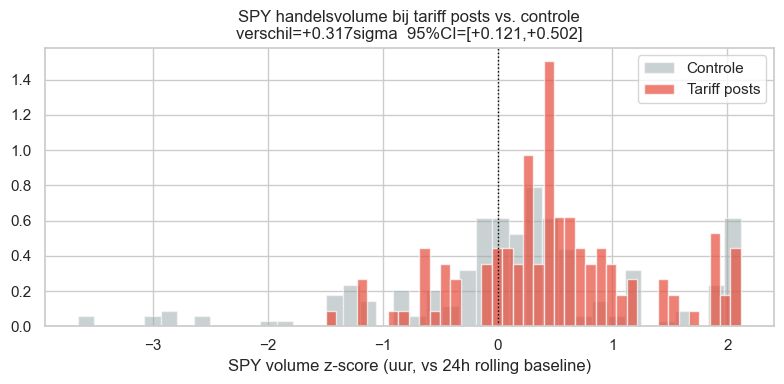

In [28]:
from src.evaluation.bootstrap import bootstrap_diff_ci

# Volume z-score uit de lokale Twelve Data 1-min parquet. Deze dekt de volledige
# tariff-periode (feb-jun 2025), i.t.t. yfinance-uurdata die maar ~60 dagen terug gaat.
spy_1m = pd.read_parquet("../data/processed/intraday_spy_tariff_1min.parquet")
spy_1m["datetime"] = pd.to_datetime(spy_1m["datetime"], utc=True)

vol_h = spy_1m.set_index("datetime")["volume"].resample("1h").sum()
vol_h = vol_h[vol_h > 0]
log_vol = np.log(vol_h.clip(lower=1))
vol_z = (log_vol - log_vol.rolling(24, min_periods=12).mean()) / log_vol.rolling(24, min_periods=12).std()

def get_vol_zscore(post_ts):
    return vol_z.get(post_ts.floor("1h"), np.nan)

intraday_start = vol_z.dropna().index.min()
tariff_z  = tariff_posts.loc[tariff_posts["timestamp_utc"] >= intraday_start, "timestamp_utc"].apply(get_vol_zscore).dropna()
control_z = control_posts.loc[control_posts["timestamp_utc"] >= intraday_start, "timestamp_utc"].apply(get_vol_zscore).dropna()

b = bootstrap_diff_ci(tariff_z, control_z, stat=np.mean)
print(f"SPY volume z-score in post-uur (Twelve Data 1-min) - {len(tariff_z)} tariff / {len(control_z)} controle")
print(f"  tariff mean={tariff_z.mean():+.3f}  |  controle mean={control_z.mean():+.3f}")
print(f"  verschil={b['obs_diff']:+.3f} sigma  95%CI=[{b['ci_low']:+.3f}, {b['ci_high']:+.3f}]  (0 uitgesloten={b['excludes_zero']})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(control_z, bins=40, alpha=0.5, density=True, color="#95a5a6", label="Controle")
ax.hist(tariff_z,  bins=40, alpha=0.7, density=True, color="#e74c3c", label="Tariff posts")
ax.axvline(0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("SPY volume z-score (uur, vs 24h rolling baseline)")
ax.set_title(f"SPY handelsvolume bij tariff posts vs. controle\n"
             f"verschil={b['obs_diff']:+.3f}sigma  95%CI=[{b['ci_low']:+.3f},{b['ci_high']:+.3f}]")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/11_tariffs_volume_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()
